In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, "/home/lilianae/projects/naf_clean")

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
from sigpy.mri import dcf

import scipy
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np


## My files
import save_data_helpers
from ksp_plot_helpers import plot_ksp_data_multichannel
import recon_functions
import recon_plot_helpers
import raw_data_utils
import coil_utils
from admm.utils_moco import golden_angle_coords_3d
from custom_recons.tv_app import TotalVariation_Phase_Stacked

## 1. Load data and crop

In [2]:
ksp_512 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject3_mid0283/patient3_mid0283_ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
print(f'ksp_512.shape = {ksp_512.shape}')

oshape = (58, 32, 32)
num_spokes = 300
ksp_reduced_spokes = ksp_512[:, :, :num_spokes, :]
print(f'ksp_reduced_spokes.shape = {ksp_reduced_spokes.shape}')

ksp_512.shape = (15, 58, 2002, 512)
ksp_reduced_spokes.shape = (15, 58, 300, 512)


## 2. Apodization using Fermi-Dirac

In [3]:
def fermi_window_kz(num_slices, num_slices_to_keep, center_slice=None, width=5.0):
    """
    Create Fermi-Dirac apodization window along slice direction
    
    Parameters
    ----------
    num_slices: int
        Total number of slices points (ldim 2 of k-space data)
    num_slices_to_keep  int
        Number of central slices to keep 
    center_slice: int, optional
        Default is num_slices // 2
    width : float
        Transition width in slices, larger = smoother rolloff
    
    Returns
    -------
    window : ndarray, shape (num_slices,)
        Symmetric Fermi window, 1 at center, rolling off to 0 at edges
    """
    if center_slice is None:
        center_slice = num_slices // 2

    # For each RO index, get radial distance from k-space center
    indices = np.arange(num_slices)

    r = np.abs(indices - center_slice)  # distance from center (0 at DC)

    # set cutoff radius r0 = num_slices_to_keep//2
    r0 = num_slices_to_keep / 2.0

    # Fermi-Dirac: 1 near center, smooth rolloff to 0 at r0
    window = 1.0 / (1.0 + np.exp((r - r0) / width))

    return window


def fermi_window_kxy(num_readouts, num_readouts_to_keep, center_readout=None, width=5.0):
    """
    Create Fermi-Dirac apodization window for a radial spoke.
    
    Parameters
    ----------
    num_readouts: int
        Total number of readout points (last dim of k-space data)
    num_readouts_to_keep  int
        Number of central readouts to keep 
    center_readout: int, optional
        Default is num_readouts // 2
    width : float
        Transition width in readout samples, larger = smoother rolloff
    
    Returns
    -------
    window : ndarray, shape (num_readouts,)
        Symmetric Fermi window, 1 at center, rolling off to 0 at edges
    """
    if center_readout is None:
        center_readout = num_readouts // 2

    # For each RO index, get radial distance from k-space center
    indices = np.arange(num_readouts)

    r = np.abs(indices - center_readout)  # distance from center (0 at DC)

    # set cutoff radius r0 = num_readouts_to_keep//2
    r0 = num_readouts_to_keep / 2.0

    # Fermi-Dirac: 1 near center, smooth rolloff to 0 at r0
    window = 1.0 / (1.0 + np.exp((r - r0) / width))

    return window


def apply_fermi_window_3d(kspace, num_slices_to_keep, num_readouts_to_keep, center_slice=None, center_readout=None, width_kz=2.0, width_kxy=5.0):
    """
    Apply Fermi-Dirac apodization to k-space along readouts

    Parameters
    ----------
    kspace: ndarray, shape (num_coils, num_slices, num_spokes, num_readouts)
    num_slices_to_keep: int 
    num_readouts_to_keep: int
    center_readout: int, optional
    width: float
        Fermi transition width in samples

    Returns
    -------
    kspace_apodized : ndarray, same shape as kspace
    """
    num_readouts = kspace.shape[-1]
    num_slices = kspace.shape[1]

    window_kz = fermi_window_kz(num_slices, num_slices_to_keep, center_slice, width_kz)

    window_kxy = fermi_window_kxy(num_readouts, num_readouts_to_keep, 
                          center_readout, width_kxy)
    

    # Broadcast over (num_coils, num_slices, num_spokes) since this is only applied over readout axis
    kspace_kxy_apo = kspace * window_kxy[np.newaxis, np.newaxis, np.newaxis, :]
    kspace_apo = kspace_kxy_apo * window_kz[np.newaxis, :, np.newaxis, np.newaxis]

    return kspace_apo

In [4]:
center_readout= 256
center_slice = 22
num_readouts_to_keep = 10
num_slices_to_keep = 10
width_kxy = 0.8
width_kz = 0.8


kspace_fermi_window = apply_fermi_window_3d(ksp_reduced_spokes, num_slices_to_keep=num_slices_to_keep,
                                            num_readouts_to_keep=num_readouts_to_keep,
                                            center_slice=center_slice, center_readout=center_readout, 
                                            width_kxy=width_kxy, width_kz=width_kz)

print(f'kspace_fermi_window.shape = {kspace_fermi_window.shape}')

kspace_fermi_window.shape = (15, 58, 300, 512)


## 3. Debug TotalVariation recon

In [5]:
def _stacked_nufft_operator_sens(
        img_shape: tuple,
        coords,
        mps) -> sp.linop.Diag:
    """setup a stacked 2D NUFFT sp operator acting on a 3D image
       the opeator first performs a 1D FFT along the "z" axis (0 or left-most axis)
       followed by applying 2D NUFFTS to all "slices"
       
    Parameters
    ----------
        img_shape: tuple
            shape of the image
        coords: (numpy or cupy) array 
            coordinates of the k-space samples
            shape (n_k_space_points,2)
            units: "unitless" -> -N/2 ... N/2 at Nyquist (sp convention)
        mps: (numpy or cupy) array
            sensitivity maps of shape (num_channels, *img_shape)

    Returns
    -------
        Diag: a stack of NUFFT operators
    """

    num_channels = len(mps)

    ft0_op = sp.linop.FFT(img_shape, axes=(0, ))

    # setup a 2D NUFFT operator for the start
    nufft_op = sp.linop.NUFFT(img_shape[1:], coords)

    # reshaping operator for input
    rs_in = sp.linop.Reshape(img_shape[1:], (1, ) + img_shape[1:])
    # setup a list of "n" 2D NUFFT operators (one per slice)
    ops = []
    for i in range(img_shape[0]):
        coords_i = coords[i].reshape(-1, coords.shape[-1])[:, 1:]  # (400*512, 2)
        nufft_op_i = sp.linop.NUFFT(img_shape[1:], coords_i)
        # Reshape NUFFT output from flat to 2D: (400*512,) -> (400, 512)
        rs_nufft = sp.linop.Reshape((coords.shape[1], coords.shape[2]), nufft_op_i.oshape)
        rs_out_i = sp.linop.Reshape((1, coords.shape[1], coords.shape[2]), (coords.shape[1], coords.shape[2]))
        ops.append(rs_out_i * rs_nufft * nufft_op_i * rs_in)


    # apply 2D NUFFTs to all "slices" using the sp Diag operator
    full_op= sp.linop.Diag(ops, iaxis=0, oaxis=0) * ft0_op
    #### Combine Sensitivity Op (mult with sens) and respective ft0+nuFFT op:

    #sensitivity = np.ones((num_channels,*img_shape),dtype=np.complex64)
    S = sp.linop.Multiply(img_shape,mps)

    rs_in_sense = sp.linop.Reshape(img_shape,(1,)+img_shape)
    rs_out_sense = sp.linop.Reshape((1,)+tuple(full_op.oshape),full_op.oshape)
    return  sp.linop.Diag(num_channels*[rs_out_sense*full_op*rs_in_sense],iaxis=0,oaxis=0)*S

TotalVariation Reconstruction

In [ ]:
ncoils, nslices, nspokes, nsamples = kspace_fermi_window.shape
img_shape = (nslices, nsamples, nsamples)

coord = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)
dcf_ksp =  save_data_helpers.read_pickle(f"dcf_cropped_{nspokes}_spokes_30RO_{nslices}_slices.pkl")

coord_gpu = sp.to_device(coord, device=0) # Move to GPU
dcf_ksp_gpu = dcf_ksp  # already on GPU

device = 0
num_coils, num_slices, num_spokes, num_readouts = kspace_fermi_window.shape

with cp.cuda.Device(device):
    low_res_recons = np.zeros((num_coils, *img_shape), dtype=np.complex64)  # CPU
    
    for i in range(1):
        print(f"\rPre-initialization: TV recon for coil {i+1}/{num_coils}", end='', flush=True)
        
        # Add coil dim: (slices, spokes, readouts) -> (1, slices, spokes, readouts)
        ksp_coil = sp.to_device(kspace_fermi_window[i][np.newaxis, ...], device=0)
        y_coil = ksp_coil * dcf_ksp_gpu[np.newaxis, ...]  # dcf also needs coil dim
        
        tv_preinit_alg = TotalVariation_Phase_Stacked(
            y=y_coil,
            mps=np.ones((1, *img_shape), dtype=np.complex128),   # (1, 58, 512, 512) -> img_shape = (58, 512, 512)
            lamda=0,
            coord=coord_gpu,
            device=device,
            z=None,
            max_iter=50,
            max_power_iter=10,
            show_pbar=True
        )
        
        result = tv_preinit_alg.run()  # shape: (58, 512, 512)
        low_res_recons[i] = sp.to_device(result, sp.cpu_device)  # move to CPU 
        
        del tv_preinit_alg, ksp_coil, y_coil, result
        cp.get_default_memory_pool().free_all_blocks()

Pre-initialization: TV recon for coil 1/15

MaxEig:   0%|          | 0/10 [00:00<?, ?it/s]

TotalVariation_Phase_Stacked:   0%|          | 0/50 [00:00<?, ?it/s]

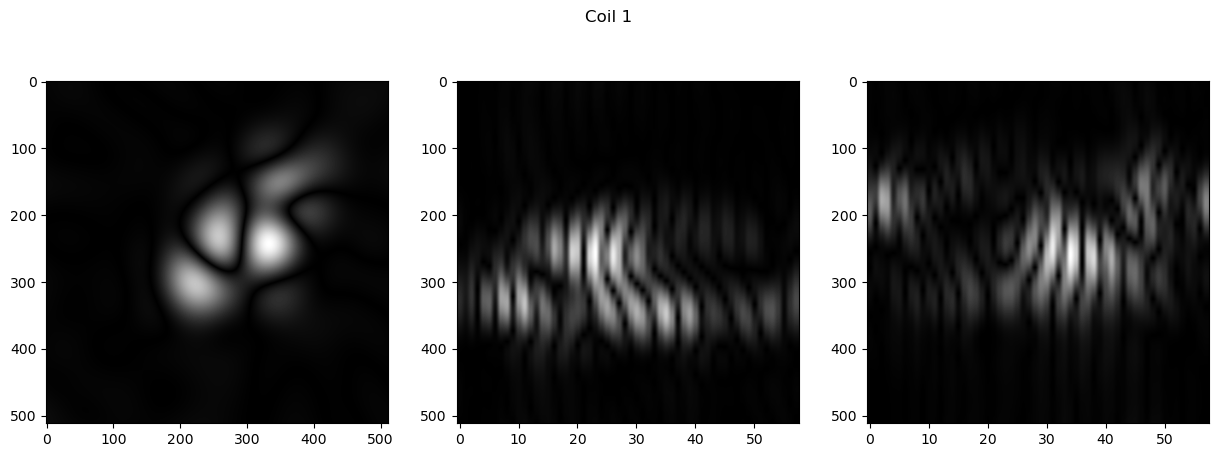

In [19]:
fig,axes = recon_plot_helpers.plot_recons_all_axes(np.imag(low_res_recons[0]), title=f'Coil 1')

Simple NUFFT recon

In [10]:
ncoils, nslices, nspokes, nsamples = kspace_fermi_window.shape
img_shape = (nslices, nsamples, nsamples)

coord = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)
dcf_ksp =  save_data_helpers.read_pickle(f"dcf_cropped_{nspokes}_spokes_30RO_{nslices}_slices.pkl")

coord_gpu = sp.to_device(coord, device=0)
dcf_ksp_gpu = dcf_ksp  # already on GPU

nufft_coil_images = np.zeros((ncoils, *img_shape), dtype=np.complex128)

for c in range(1):
    print(f"Reconstructing coil {c+1}/{ncoils}...")
    
    # Move one coil to GPU, apply DCF, reconstruct
    ksp_coil = sp.to_device(kspace_fermi_window[c], device=0)  # (nslices, nspokes, nsamples)
    coil_img = sp.nufft_adjoint(ksp_coil * dcf_ksp_gpu, coord_gpu, oshape=img_shape)
    
    nufft_coil_images[c] = sp.to_device(coil_img, device=0).get()
    del ksp_coil, coil_img
    cp.get_default_memory_pool().free_all_blocks()  # aggressively free GPU cache

Reconstructing coil 1/15...


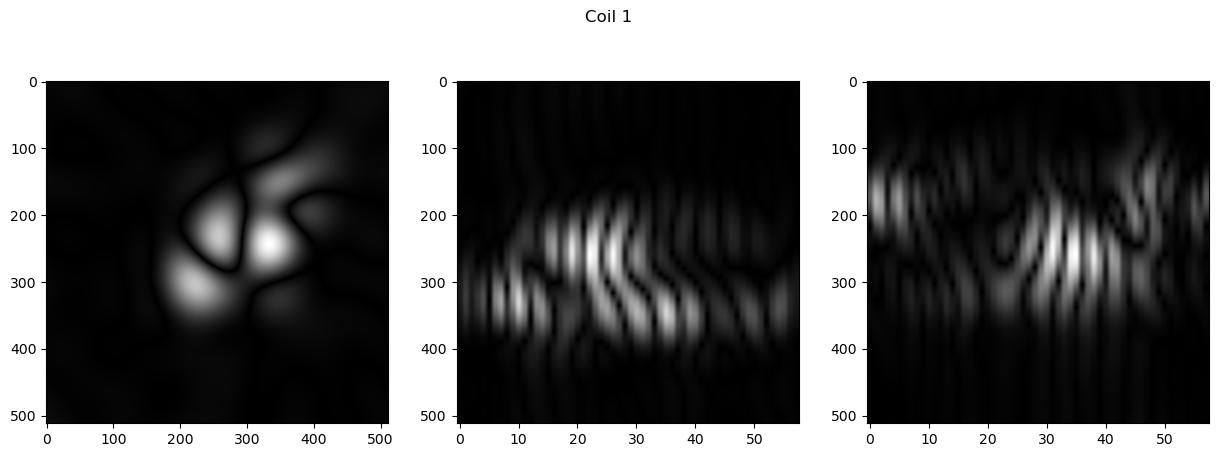

In [13]:
fig,axes = recon_plot_helpers.plot_recons_all_axes(np.imag(nufft_coil_images[0]), title=f'Coil 1')

In [14]:
## Phase difference
phase_diff = np.imag(low_res_recons[0]) - np.imag(nufft_coil_images[0])
print(phase_diff.shape)

(58, 512, 512)


In [17]:
print(np.mean(np.imag(low_res_recons[0])))
print(np.mean(np.imag(nufft_coil_images[0])))

-7.695287e-05
1.0528658687431937e-28
